In [4]:
import pandas as pd
df = pd.read_csv("cropdata_updated.csv")
print(df.head())

  crop ID   soil_type Seedling Stage  MOI  temp  humidity  result
0   Wheat  Black Soil    Germination    1    25      80.0       1
1   Wheat  Black Soil    Germination    2    26      77.0       1
2   Wheat  Black Soil    Germination    3    27      74.0       1
3   Wheat  Black Soil    Germination    4    28      71.0       1
4   Wheat  Black Soil    Germination    5    29      68.0       1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


In [11]:
df.isnull().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


In [12]:
df.duplicated().sum()

np.int64(128)

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(16283, 7)

In [16]:
df["result"].value_counts()

,count
result,
0,8934
1,6227
2,1122


In [17]:
df["result"].value_counts(normalize=True) * 100

,proportion
result,
0,54.867039
1,38.242339
2,6.890622


In [18]:
X = df.drop("result", axis=1)

y = df["result"]

In [19]:
print(X.head())
print(y.head())

  crop ID   soil_type Seedling Stage  MOI  temp  humidity
0   Wheat  Black Soil    Germination    1    25      80.0
1   Wheat  Black Soil    Germination    2    26      77.0
2   Wheat  Black Soil    Germination    3    27      74.0
3   Wheat  Black Soil    Germination    4    28      71.0
4   Wheat  Black Soil    Germination    5    29      68.0
0    1
1    1
2    1
3    1
4    1
Name: result, dtype: int64


In [20]:
X.dtypes

,0
crop ID,object
soil_type,object
Seedling Stage,object
MOI,int64
temp,int64
humidity,float64


In [21]:
from sklearn.preprocessing import LabelEncoder

crop_encoder = LabelEncoder()
soil_encoder = LabelEncoder()
stage_encoder = LabelEncoder()

X["crop ID"] = crop_encoder.fit_transform(X["crop ID"])
X["soil_type"] = soil_encoder.fit_transform(X["soil_type"])
X["Seedling Stage"] = stage_encoder.fit_transform(X["Seedling Stage"])

In [22]:
X.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity
0,4,1,2,1,25,80.0
1,4,1,2,2,26,77.0
2,4,1,2,3,27,74.0
3,4,1,2,4,28,71.0
4,4,1,2,5,29,68.0


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(13026, 6)
(3257, 6)
(13026,)
(3257,)


In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9904820386859072


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1818
           1       0.99      1.00      0.99      1237
           2       0.97      0.88      0.92       202

    accuracy                           0.99      3257
   macro avg       0.98      0.96      0.97      3257
weighted avg       0.99      0.99      0.99      3257



In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1813    1    4]
 [   0 1235    2]
 [   8   16  178]]


In [30]:
import joblib

joblib.dump(model, "irrigation_model.pkl")

['irrigation_model.pkl']

In [31]:
joblib.dump(crop_encoder, "crop_encoder.pkl")
joblib.dump(soil_encoder, "soil_encoder.pkl")
joblib.dump(stage_encoder, "stage_encoder.pkl")

['stage_encoder.pkl']

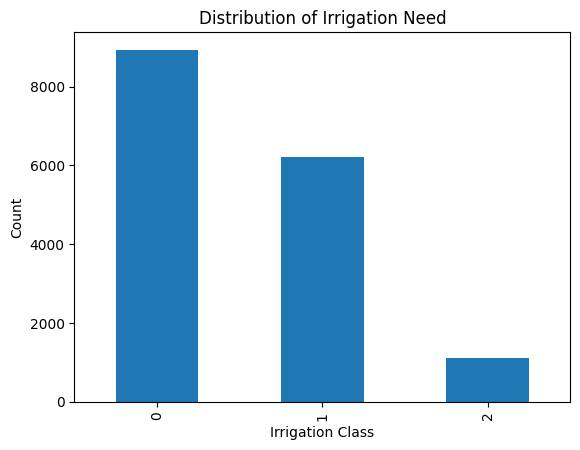

In [32]:
import matplotlib.pyplot as plt

df["result"].value_counts().plot(kind="bar")
plt.xlabel("Irrigation Class")
plt.ylabel("Count")
plt.title("Distribution of Irrigation Need")
plt.show()

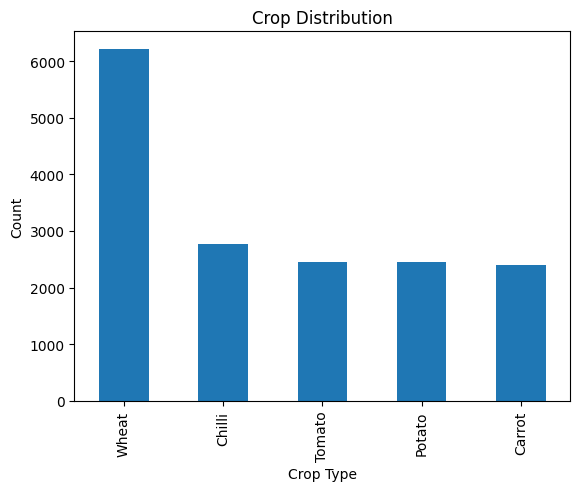

In [33]:
df["crop ID"].value_counts().plot(kind="bar")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.title("Crop Distribution")
plt.show()

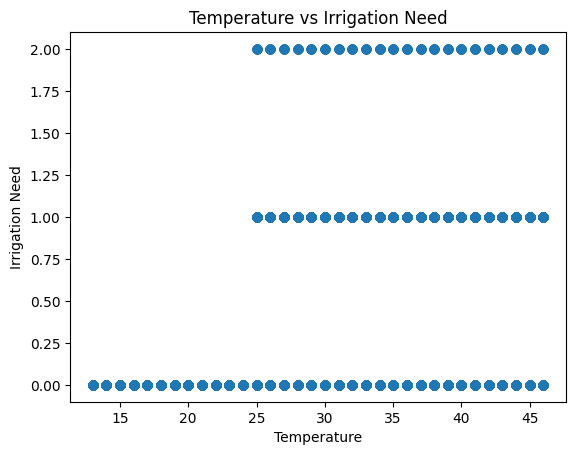

In [34]:
plt.scatter(df["temp"], df["result"])
plt.xlabel("Temperature")
plt.ylabel("Irrigation Need")
plt.title("Temperature vs Irrigation Need")
plt.show()

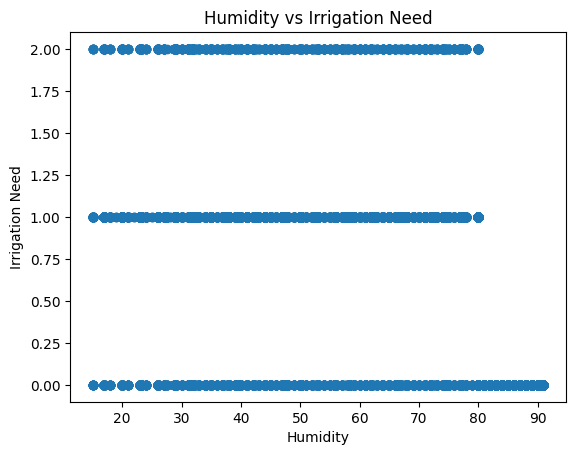

In [35]:
plt.scatter(df["humidity"], df["result"])
plt.xlabel("Humidity")
plt.ylabel("Irrigation Need")
plt.title("Humidity vs Irrigation Need")
plt.show()

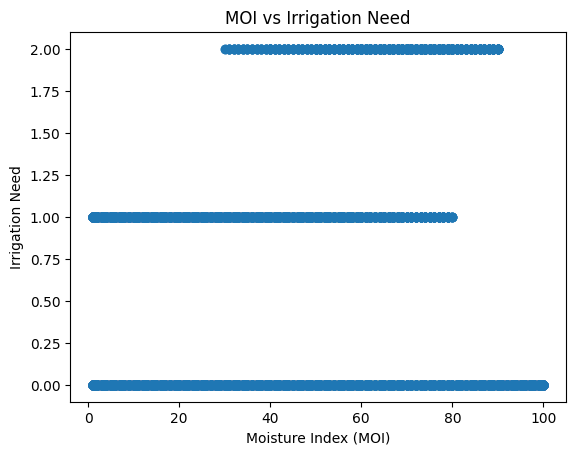

In [36]:
plt.scatter(df["MOI"], df["result"])
plt.xlabel("Moisture Index (MOI)")
plt.ylabel("Irrigation Need")
plt.title("MOI vs Irrigation Need")
plt.show()